# Моделирование работы производственного цеха

## Введение

Данный Jupyter Notebook представляет собой симуляционную модель работы производственного цеха с использованием библиотеки `simpy`. Цель моделирования - исследовать влияние различных режимов работы ремонтных бригад на производительность станков, количество простоев и ремонтов. Мы сравним две основные конфигурации:

1.  **Базовая модель**: Ремонтники работают в одну смену, одновременно.
2.  **Модель с двумя сменами**: Ремонтники работают посменно, обеспечивая более длительное покрытие рабочего времени.

Модель учитывает следующие ключевые параметры:

* Время изготовления детали на станке (среднее и стандартное отклонение).
* Среднее время между поломками станков (MTTF).
* Среднее время ремонта станка.
* Количество станков в цехе.
* Общая длительность моделирования.

В результате моделирования будут собраны данные о количестве произведенных деталей, числе ремонтов, а также общем времени простоев и ремонтов для каждого станка. Полученные данные будут визуализированы с помощью различных графиков для удобного анализа и сравнения эффективности двух режимов работы.

In [1]:
# Установка необходимых библиотек
!pip install simpy numpy matplotlib

## Импорт библиотек и определение глобальных параметров

В этом блоке мы импортируем все необходимые библиотеки и определяем константы, которые будут использоваться во всей модели. Эти параметры задают основные характеристики симуляции, такие как время работы, количество ресурсов и статистические данные о процессах.

In [2]:
import random
import simpy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Установка стиля графиков для лучшей визуализации
plt.style.use('seaborn-v0_8-darkgrid')

# --- Глобальные параметры симуляции ---
RANDOM_SEED = 4210         # Начальное значение для генератора случайных чисел для воспроизводимости
PT_MEAN = 20.0             # Среднее время изготовления детали на станке (мин)
PT_SIGMA = 4.0             # Стандартное отклонение времени изготовления детали (мин)
MTTF = 1000.0              # Среднее время между поломками (Mean Time To Failure) (мин)
REPAIR_TIME = 30.0         # Среднее время ремонта станка (мин)
NUM_MACHINES = 5           # Количество станков в цехе
NUM_REPAIRMEN = 2          # Количество ремонтников
WEEKS = 2                  # Время моделирования в неделях
SIM_TIME = WEEKS * 7 * 24 * 60  # Общее время моделирования в минутах (недели * дни * часы * минуты)

# --- Глобальные переменные для сбора статистики ---
men_at_work = []           # Журнал состояния ремонтников (время, состояние)
machine_states_history = []  # Журнал истории состояний каждого станка (для пост-анализа)


## Класс `Machine`

Класс `Machine` представляет собой отдельный станок в производственном цехе. Каждый станок моделируется как процесс, который производит детали и может ломаться. При поломке станок запрашивает ремонтника, и его работа приостанавливается до завершения ремонта.

### Логика работы:

1.  **Инициализация (`__init__`)**: 
    * Устанавливает идентификатор станка.
    * Инициализирует счетчики произведенных деталей, количества ремонтов, общей длительности ремонтов и простоев.
    * Начинает два параллельных процесса: `working` (производство деталей) и `break_machine` (генерация поломок).
    * Записывает начальное состояние станка (работает) в историю состояний.

2.  **Процесс `working` (работа станка)**:
    * Симулирует изготовление детали с нормально распределенным временем.
    * В случае прерывания (поломки): 
        * Фиксирует время поломки и длительность простоя.
        * Изменяет состояние станка на 'сломан' и записывает в историю.
        * Запрашивает ремонтника с высоким приоритетом (чтобы ремонтники не отдыхали, если станки сломаны).
        * Ожидает доступности ремонтника.
        * После получения ремонтника, фиксирует начало ремонта, меняет состояние на 'ремонтируется' и моделирует время ремонта (равномерное распределение вокруг среднего).
        * После ремонта, станок снова становится 'работающим', фиксирует длительность ремонта и простоя, и возобновляет производство детали.
    * После успешного изготовления детали увеличивает счетчик `parts_made`.

3.  **Процесс `break_machine` (поломка станка)**:
    * Генерирует поломки станка через экспоненциально распределенные интервалы времени (моделируя случайность отказов).
    * Прерывает текущий процесс `working` станка, если он не сломан.

In [3]:
class Machine(object):
    """Класс, представляющий отдельный станок в производственном цехе.
    Станок производит детали и может ломаться, требуя ремонта.
    """
    def __init__(self, env, num, repairman):
        self.env = env # Среда SimPy
        self.parts_made = 0  # Количество сделанных станком деталей
        self.broken = False  # Флаг состояния: True, если станок сломан
        self.ID = num + 1  # Уникальный идентификатор станка (начиная с 1)
        self.repair_cnt = 0  # Количество проведенных ремонтов станка
        self.totalFixDuration = 0  # Общая длительность всех ремонтов станка
        self.totalFailureDuration = 0  # Общая длительность всех простоев из-за поломок
        self.state_history = []  # История состояний станка (время, состояние: 0-работает, 1-сломан, 2-ремонтируется)
        self.state_history.append((0, 0))  # Начальное состояние - работает (в момент времени 0)

        # Запуск процессов работы и поломки станка в среде SimPy
        self.workprocess = env.process(self.working(repairman))
        env.process(self.break_machine())

    def working(self, repairman):
        """Процесс работы станка: производство деталей и обработка поломок.
        При поломке станок запрашивает ремонтника и ожидает ремонта.
        """
        while True:
            # Определяем время изготовления новой детали (нормальное распределение)
            self.done_time = random.normalvariate(PT_MEAN, PT_SIGMA)
            # Гарантируем, что время изготовления положительное
            if self.done_time < 0: self.done_time = PT_MEAN

            while self.done_time > 0:
                try:
                    # Станок делает деталь
                    self.start_work_segment = self.env.now # Время начала текущего сегмента работы
                    yield self.env.timeout(self.done_time)
                    self.parts_made += 1  # Деталь доделана
                    self.done_time = 0    # Сброс оставшегося времени на деталь
                except simpy.Interrupt:
                    # Станок был прерван (сломался)
                    self.broken = True  # Устанавливаем флаг поломки
                    self.break_time = self.env.now  # Фиксируем время поломки
                    # Вычисляем, сколько времени оставалось доделать деталь
                    self.done_time -= (self.env.now - self.start_work_segment)
                    self.state_history.append((self.env.now, 1))  # Записываем состояние: сломан

                    # Запрос ремонтника с высоким приоритетом
                    with repairman.request(priority=1) as req: 
                        yield req  # Ожидаем доступности ремонтника
                        
                        self.repair_cnt += 1  # Увеличиваем счетчик ремонтов
                        self.fix_time = self.env.now  # Фиксируем время начала ремонта
                        self.state_history.append((self.env.now, 2))  # Записываем состояние: ремонтируется
                        
                        # Моделируем время ремонта (равномерное распределение вокруг среднего)
                        yield self.env.timeout(random.uniform(REPAIR_TIME * 0.8, REPAIR_TIME * 1.2))
                    
                    self.broken = False   # Станок восстановлен
                    self.state_history.append((self.env.now, 0))  # Записываем состояние: работает
                    
                    # Вычисляем и накапливаем длительности ремонта и простоя
                    self.fix_duration = self.env.now - self.fix_time
                    self.totalFixDuration += self.fix_duration
                    
                    self.failure_duration = self.env.now - self.break_time
                    self.totalFailureDuration += self.failure_duration

    def break_machine(self):
        """Процесс поломки станка: генерирует события поломок.
        Поломки происходят через экспоненциально распределенные интервалы.
        """
        while True:
            # Ожидаем время до следующей поломки (экспоненциальное распределение)
            yield self.env.timeout(random.expovariate(1.0 / MTTF))
            # Если станок не сломан, прерываем его текущую работу
            if not self.broken: 
                self.workprocess.interrupt()

## Функция `work_sched`

Эта функция моделирует расписание работы ремонтников. Она управляет доступностью ремонтных бригад в зависимости от выбранного режима работы (одна или две смены).

### Логика работы:

1.  **Инициализация**: 
    * В начале симуляции, если ремонтники не на работе (например, до 8 утра), они "заняты" отдыхом. Это достигается путем создания запросов на ресурс `repairman` с низким приоритетом, которые не освобождаются.
    * Записывается начальное состояние ремонтников (отдых) в журнал `men_at_work`.

2.  **Режим "одна смена" (`two_shifts=False`)**:
    * В начале каждого рабочего дня (в 8:00 утра) все ремонтники освобождаются от "отдыха" и становятся доступными для выполнения ремонтов.
    * Устанавливается флаг `at_work = True`.
    * Рабочий день длится 8 часов.
    * По окончании рабочего дня ремонтники снова "занимаются" отдыхом (создаются новые запросы на ресурс).
    * Устанавливается флаг `at_work = False`.
    * Расчет времени до начала следующего рабочего дня учитывает возможную переработку.

3.  **Режим "две смены" (`two_shifts=True`)**:
    * В начале дня (в 8:00 утра) первый ремонтник выходит на работу, второй остается "занятым" отдыхом.
    * Первая смена длится 8 часов.
    * По окончании первой смены первый ремонтник уходит на "отдых", а второй выходит на работу (освобождается).
    * Вторая смена также длится 8 часов.
    * По окончании второй смены второй ремонтник уходит на "отдых", и все ремонтники становятся "занятыми" отдыхом.
    * Расчет времени до начала следующего дня - 8 часов (до начала первой смены следующего дня).

Журнал `men_at_work` отслеживает изменения состояния ремонтников (отдых, работающая смена 1, работающая смена 2) для последующей визуализации.

In [4]:
def work_sched(env, repairman, two_shifts=False):
    """Процесс, управляющий расписанием работы ремонтников.
    Позволяет моделировать одну или две смены работы.
    """
    global men_at_work
    
    # Список запросов на ресурс для удержания ремонтников "на отдыхе"
    # Изначально все ремонтники "заняты" отдыхом до начала рабочего дня
    rep_requests = [0] * repairman.capacity
    for r in range(repairman.capacity):
       rep_requests[r] = repairman.request(priority=2) # Приоритет ниже, чем у поломки
       yield rep_requests[r]
    
    men_at_work.append((0, env.now))  # Записываем в журнал: (0 - не работает / отдых)
    
    day_start_offset = 8 * 60 # Рабочий день начинается в 8:00 (относительно начала суток)

    if not two_shifts:
        # --- Режим одной смены ---
        while True:
            # Ожидание до начала рабочего дня (8:00)
            current_minute_of_day = env.now % (24 * 60)
            if current_minute_of_day < day_start_offset:
                yield env.timeout(day_start_offset - current_minute_of_day)
            elif current_minute_of_day > day_start_offset:
                yield env.timeout((24 * 60) - current_minute_of_day + day_start_offset)
            
            # Ремонтники начинают работу: освобождаем их от "отдыха"
            for r in range(repairman.capacity):
                repairman.release(rep_requests[r])
            
            men_at_work.append((1, env.now))  # Записываем в журнал: (1 - все ремонтники работают)
            
            # Рабочий день длится 8 часов
            yield env.timeout(8 * 60)
            
            # Ремонтники заканчивают работу: снова "занимаются" отдыхом
            for r in range(repairman.capacity):
               rep_requests[r] = repairman.request(priority=2)
               yield rep_requests[r]
            
            men_at_work.append((0, env.now))  # Записываем в журнал: (0 - не работает / отдых)
            
            # Ожидание до начала следующего рабочего дня (24 часа от текущего момента)
            yield env.timeout(16 * 60) # 16 часов до следующего 8:00
    else:
        # --- Режим двух смен ---
        while True:
            # Ожидание до начала первой смены (8:00)
            current_minute_of_day = env.now % (24 * 60)
            if current_minute_of_day < day_start_offset:
                yield env.timeout(day_start_offset - current_minute_of_day)
            elif current_minute_of_day > day_start_offset:
                yield env.timeout((24 * 60) - current_minute_of_day + day_start_offset)

            # Первая смена (ремонтник 1) выходит на работу
            repairman.release(rep_requests[0])
            men_at_work.append((1, env.now))  # Записываем в журнал: (1 - работает первая смена)
            yield env.timeout(8 * 60) # Первая смена работает 8 часов
            
            # Пересмена: первый ремонтник уходит, второй выходит
            rep_requests[0] = repairman.request(priority=2)
            yield rep_requests[0] # Первый ремонтник снова "на отдыхе"
            repairman.release(rep_requests[1])
            men_at_work.append((2, env.now))  # Записываем в журнал: (2 - работает вторая смена)
            yield env.timeout(8 * 60) # Вторая смена работает 8 часов
            
            # Конец рабочего дня: второй ремонтник уходит
            rep_requests[1] = repairman.request(priority=2)
            yield rep_requests[1] # Второй ремонтник снова "на отдыхе"
            men_at_work.append((0, env.now))  # Записываем в журнал: (0 - не работает / отдых)
            
            # Ожидание до начала первой смены следующего дня (8 часов)
            yield env.timeout(8 * 60)

## Функция `run_model`

Функция `run_model` инкапсулирует процесс инициализации и запуска симуляции. Она позволяет легко запускать модель с различными конфигурациями, такими как количество смен ремонтников.

### Логика работы:

1.  **Сброс глобальных переменных**: Перед каждым запуском модели очищаются журналы `men_at_work` и `machine_states_history`, чтобы обеспечить независимость результатов между запусками.

2.  **Инициализация среды**: Создается новая среда `simpy.Environment()`.

3.  **Создание ресурсов**: 
    * Создается ресурс `simpy.PriorityResource` для ремонтников. `PriorityResource` позволяет отдавать предпочтение запросам с более высоким приоритетом (например, поломкам станков).
    * Создаются экземпляры класса `Machine` для каждого станка в цехе, передавая им среду и ресурс ремонтников.

4.  **Запуск процессов**: Запускается процесс `work_sched`, который управляет расписанием ремонтников, а также процессы `working` и `break_machine` для каждого станка (запускаются в конструкторе `Machine`).

5.  **Выполнение симуляции**: `env.run(until=SIM_TIME)` запускает симуляцию до заданного общего времени.

6.  **Сбор данных**: После завершения симуляции собирается история состояний каждого станка и сохраняется в `machine_states_history`.

7.  **Возврат результатов**: Функция возвращает список объектов `Machine`, содержащих всю накопленную статистику по каждому станку.

In [5]:
def run_model(two_shifts=False):
    """Запускает симуляционную модель производственного цеха.
    Args:
        two_shifts (bool): Если True, ремонтники работают в две смены; иначе - в одну.
    Returns:
        list: Список объектов Machine, содержащих результаты симуляции для каждого станка.
    """
    global men_at_work, machine_states_history
    men_at_work = []           # Сброс журнала состояния ремонтников
    machine_states_history = []  # Сброс журнала истории состояний станков
    
    random.seed(RANDOM_SEED) # Установка seed для воспроизводимости каждого запуска

    # Создание среды SimPy
    env = simpy.Environment()
    
    # Создание ресурса для ремонтников с приоритетом (высокий приоритет для поломок)
    repairmen = simpy.PriorityResource(env, capacity=NUM_REPAIRMEN)
    
    # Создание экземпляров станков
    machines = [Machine(env, i, repairmen) for i in range(NUM_MACHINES)]
    
    # Запуск процесса планирования работы ремонтников
    env.process(work_sched(env, repairmen, two_shifts))
    
    # Запуск симуляции до заданного времени
    env.run(until=SIM_TIME)
    
    # Сбор данных о состоянии каждого станка после завершения симуляции
    for m in machines:
        machine_states_history.append(m.state_history)
    
    return machines

## Запуск и анализ базовой модели (одна смена)

В этом разделе мы запускаем симуляцию с базовой конфигурацией, где ремонтники работают в одну смену. После завершения симуляции собираются и выводятся основные метрики производительности и эффективности, а затем результаты визуализируются.

### Собираемые метрики:

* **`parts_made`**: Количество деталей, произведенных каждым станком.
* **`repair_counts`**: Количество ремонтов, выполненных для каждого станка.
* **`fix_durations`**: Суммарная длительность всех ремонтов для каждого станка.
* **`failure_durations`**: Суммарная длительность всех простоев из-за поломок для каждого станка.

### Визуализация:

1.  **Режим работы ремонтников**: График, показывающий состояние ремонтников (отдых/работа) во времени.
2.  **Гистограммы и круговые диаграммы**: 
    * Сравнение сделанных деталей по станкам.
    * Сравнение количества ремонтов по станкам.
    * Сравнение длительности ремонтов по станкам.
    * Сравнение длительности простоев по станкам.
3.  **Круговые диаграммы состояний станков**: Для каждого станка показывается процент времени, проведенного в состояниях 'работает', 'сломан' и 'ремонтируется'.


--- Запуск базовой модели (одна смена ремонтников) ---

Результаты работы цеха за 2 недели (20160 мин) - Базовая модель:
  Станок Prn_1: сделано 702 деталей, проведено 10 ремонтов, простои: 6119.73 мин, ремонты: 280.50 мин
  Станок Prn_2: сделано 651 деталей, проведено 16 ремонтов, простои: 5596.76 мин, ремонты: 487.00 мин
  Станок Prn_3: сделано 764 деталей, проведено 14 ремонтов, простои: 4072.50 мин, ремонты: 436.52 мин
  Станок Prn_4: сделано 743 деталей, проведено 14 ремонтов, простои: 4290.92 мин, ремонты: 420.23 мин
  Станок Prn_5: сделано 743 деталей, проведено 14 ремонтов, простои: 3620.61 мин, ремонты: 420.84 мин

Общее количество деталей (базовая): 3603
Общее время простоев станков (базовая): 23700.52 мин
Общее время ремонтов станков (базовая): 2045.09 мин


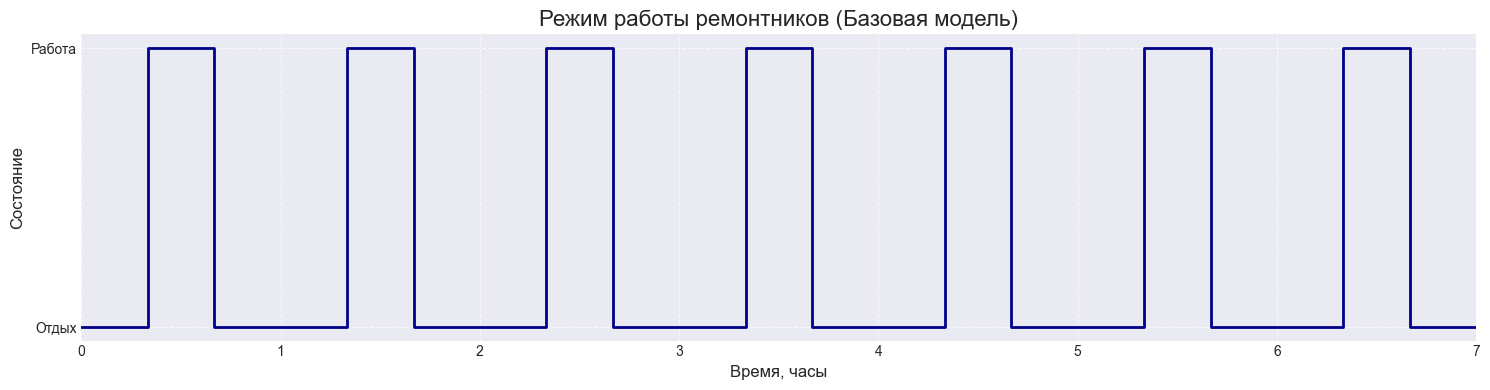

/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_33156/2896082043.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=parts_made_base, ax=axes[0, 0], palette='viridis')
/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_33156/2896082043.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=repair_counts_base, ax=axes[0, 1], palette='plasma')
/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_33156/2896082043.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=failure_durations_ba

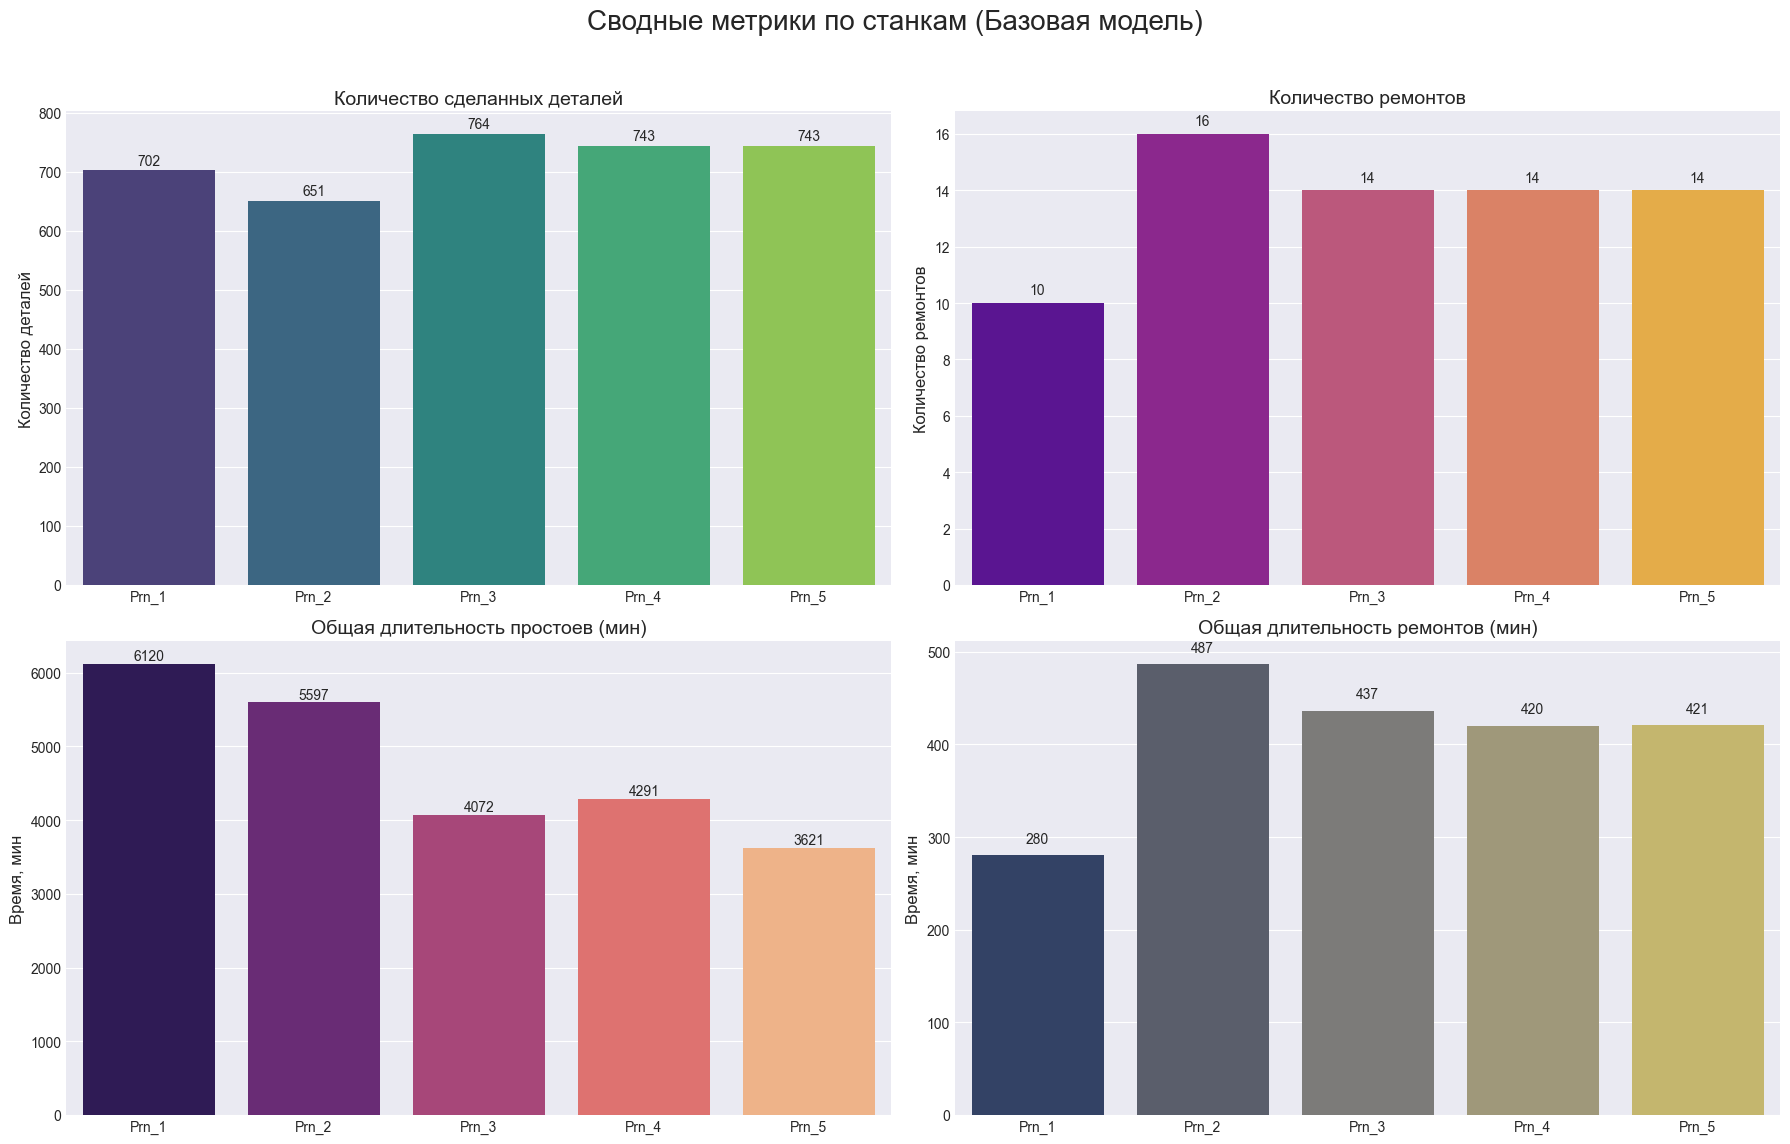

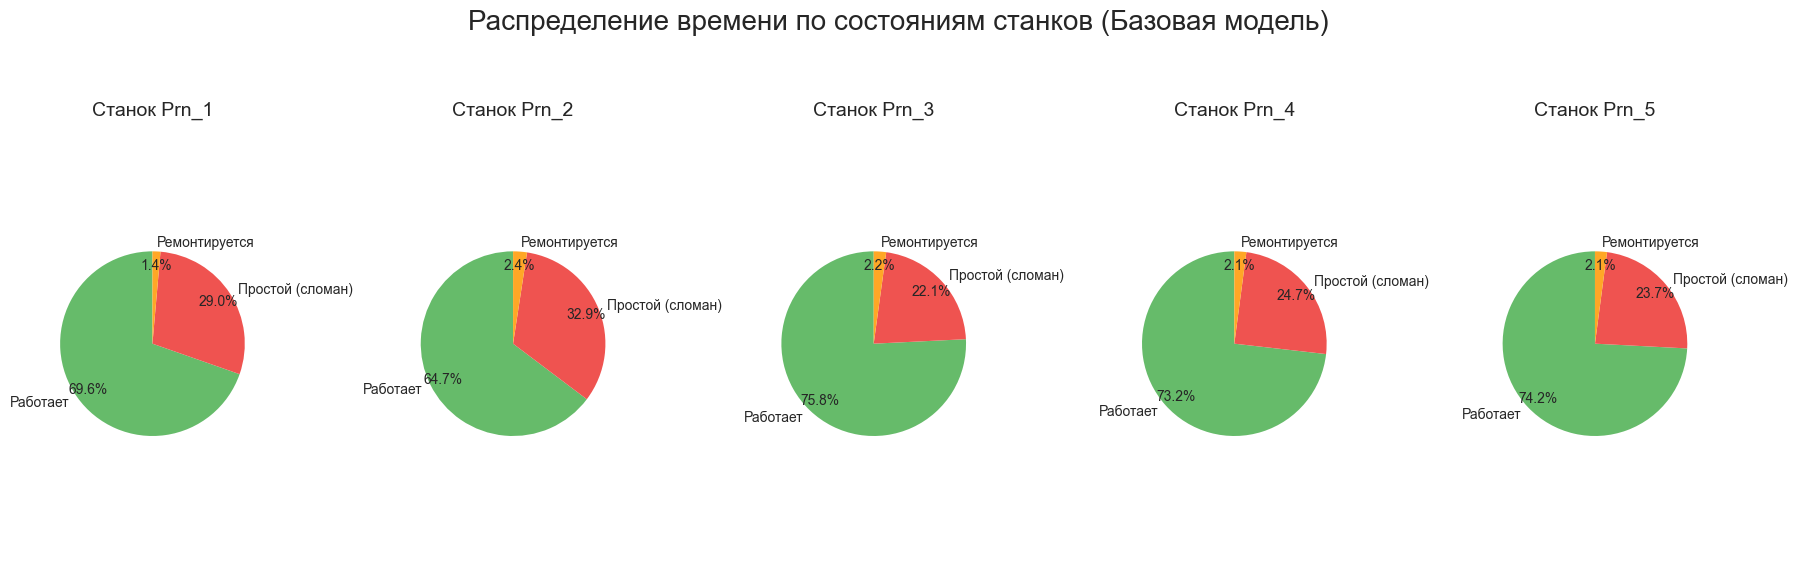

In [6]:
print("\n--- Запуск базовой модели (одна смена ремонтников) ---")
machines_base = run_model(two_shifts=False)

print(f'\nРезультаты работы цеха за {WEEKS} недели ({SIM_TIME} мин) - Базовая модель:')

parts_made_base = [m.parts_made for m in machines_base]
repair_counts_base = [m.repair_cnt for m in machines_base]
fix_durations_base = [m.totalFixDuration for m in machines_base]
failure_durations_base = [m.totalFailureDuration for m in machines_base]

for m in machines_base:
    print(f'  Станок Prn_{m.ID}: сделано {m.parts_made} деталей, проведено {m.repair_cnt} ремонтов, простои: {m.totalFailureDuration:.2f} мин, ремонты: {m.totalFixDuration:.2f} мин')

print(f'\nОбщее количество деталей (базовая): {sum(parts_made_base)}')
print(f'Общее время простоев станков (базовая): {sum(failure_durations_base):.2f} мин')
print(f'Общее время ремонтов станков (базовая): {sum(fix_durations_base):.2f} мин')

# --- Визуализация результатов базовой модели ---

# 1. График состояния ремонтников (базовая модель)
plt.figure(figsize=(15, 4))
plt.step([p[1] for p in men_at_work], [p[0] for p in men_at_work], where='post', lw=2, color='darkblue')
plt.title('Режим работы ремонтников (Базовая модель)', fontsize=16)
plt.xlabel('Время, часы', fontsize=12)
plt.ylabel('Состояние', fontsize=12)
plt.yticks([0, 1], ['Отдых', 'Работа'], fontsize=10)
plt.xticks(np.arange(0, SIM_TIME + 1, 24*60), [f'{int(x/(24*60))}' for x in np.arange(0, SIM_TIME + 1, 24*60)], fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 7 * 24 * 60) # Показываем только первую неделю для ясности
plt.tight_layout()
plt.show()

# 2. Гистограммы сравнения по станкам (Базовая модель)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Сводные метрики по станкам (Базовая модель)', fontsize=20)
labels = [f'Prn_{i+1}' for i in range(NUM_MACHINES)]
x = np.arange(NUM_MACHINES)
width = 0.6

# Сделано деталей
sns.barplot(x=labels, y=parts_made_base, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Количество сделанных деталей', fontsize=14)
axes[0, 0].set_ylabel('Количество деталей', fontsize=12)
for index, value in enumerate(parts_made_base):
    axes[0, 0].text(index, value + 5, str(value), ha='center', va='bottom', fontsize=10)

# Количество ремонтов
sns.barplot(x=labels, y=repair_counts_base, ax=axes[0, 1], palette='plasma')
axes[0, 1].set_title('Количество ремонтов', fontsize=14)
axes[0, 1].set_ylabel('Количество ремонтов', fontsize=12)
for index, value in enumerate(repair_counts_base):
    axes[0, 1].text(index, value + 0.2, str(value), ha='center', va='bottom', fontsize=10)

# Длительность простоев
sns.barplot(x=labels, y=failure_durations_base, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Общая длительность простоев (мин)', fontsize=14)
axes[1, 0].set_ylabel('Время, мин', fontsize=12)
for index, value in enumerate(failure_durations_base):
    axes[1, 0].text(index, value + 10, f'{value:.0f}', ha='center', va='bottom', fontsize=10)

# Длительность ремонтов
sns.barplot(x=labels, y=fix_durations_base, ax=axes[1, 1], palette='cividis')
axes[1, 1].set_title('Общая длительность ремонтов (мин)', fontsize=14)
axes[1, 1].set_ylabel('Время, мин', fontsize=12)
for index, value in enumerate(fix_durations_base):
    axes[1, 1].text(index, value + 10, f'{value:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Учитываем общий заголовок
plt.show()

# 3. Круговые диаграммы состояний станков (Базовая модель)
fig, axes = plt.subplots(1, NUM_MACHINES, figsize=(18, 6))
fig.suptitle('Распределение времени по состояниям станков (Базовая модель)', fontsize=20)
state_labels = ['Работает', 'Простой (сломан)', 'Ремонтируется']
colors = ['#66bb6a', '#ef5350', '#ffa726'] # Красивые цвета для состояний

for i in range(NUM_MACHINES):
    # Рассчитаем время в каждом состоянии для каждого станка
    state_times = [0, 0, 0] # 0-работает, 1-сломан, 2-ремонтируется
    machine_history = machine_states_history[i]

    for j in range(len(machine_history) - 1):
        current_time, current_state = machine_history[j]
        next_time, _ = machine_history[j + 1]
        duration = next_time - current_time
        state_times[current_state] += duration
    
    # Добавляем время последнего состояния до конца симуляции
    last_time, last_state = machine_history[-1]
    state_times[last_state] += SIM_TIME - last_time

    # Отфильтровываем состояния с нулевой длительностью для лучшего отображения
    filtered_labels = [state_labels[k] for k, val in enumerate(state_times) if val > 0]
    filtered_times = [val for val in state_times if val > 0]
    filtered_colors = [colors[k] for k, val in enumerate(state_times) if val > 0]

    axes[i].pie(filtered_times, labels=filtered_labels, colors=filtered_colors, 
                autopct='%1.1f%%', startangle=90, pctdistance=0.85, textprops={'fontsize': 10})
    axes[i].set_title(f'Станок Prn_{i+1}', fontsize=14)
    axes[i].axis('equal') # Обеспечивает круговую форму

plt.tight_layout(rect=[0, 0.03, 1, 0.92]) # Учитываем общий заголовок
plt.show()

## Запуск и анализ модели с двумя сменами

В этом разделе мы запускаем симуляцию с конфигурацией, где ремонтники работают в две смены. Это должно обеспечить более полное покрытие рабочего времени и потенциально сократить время простоев. Аналогично базовой модели, после завершения симуляции собираются, выводятся и визуализируются ключевые метрики.

### Собираемые метрики:

* **`parts_made_ts`**: Количество деталей, произведенных каждым станком.
* **`repair_counts_ts`**: Количество ремонтов, выполненных для каждого станка.
* **`fix_durations_ts`**: Суммарная длительность всех ремонтов для каждого станка.
* **`failure_durations_ts`**: Суммарная длительность всех простоев из-за поломок для каждого станка.

### Визуализация:

1.  **Режим работы ремонтников**: График, показывающий состояние ремонтников (отдых/смена 1/смена 2) во времени.
2.  **Гистограммы и круговые диаграммы**: Аналогичные базовой модели, но для режима с двумя сменами.
3.  **Круговые диаграммы состояний станков**: Для каждого станка показывается процент времени, проведенного в состояниях 'работает', 'сломан' и 'ремонтируется' для режима с двумя сменами.


--- Запуск модели с двумя сменами ремонтников ---

Результаты работы цеха за 2 недели (20160 мин) - Модель с двумя сменами:
  Станок Prn_1: сделано 722 деталей, проведено 21 ремонтов, простои: 5582.87 мин, ремонты: 627.83 мин
  Станок Prn_2: сделано 843 деталей, проведено 10 ремонтов, простои: 3106.97 мин, ремонты: 285.99 мин
  Станок Prn_3: сделано 793 деталей, проведено 12 ремонтов, простои: 4308.77 мин, ремонты: 334.35 мин
  Станок Prn_4: сделано 853 деталей, проведено 18 ремонтов, простои: 3125.83 мин, ремонты: 508.56 мин
  Станок Prn_5: сделано 764 деталей, проведено 19 ремонтов, простои: 4871.73 мин, ремонты: 567.57 мин

Общее количество деталей (две смены): 3975
Общее время простоев станков (две смены): 20996.17 мин
Общее время ремонтов станков (две смены): 2324.31 мин


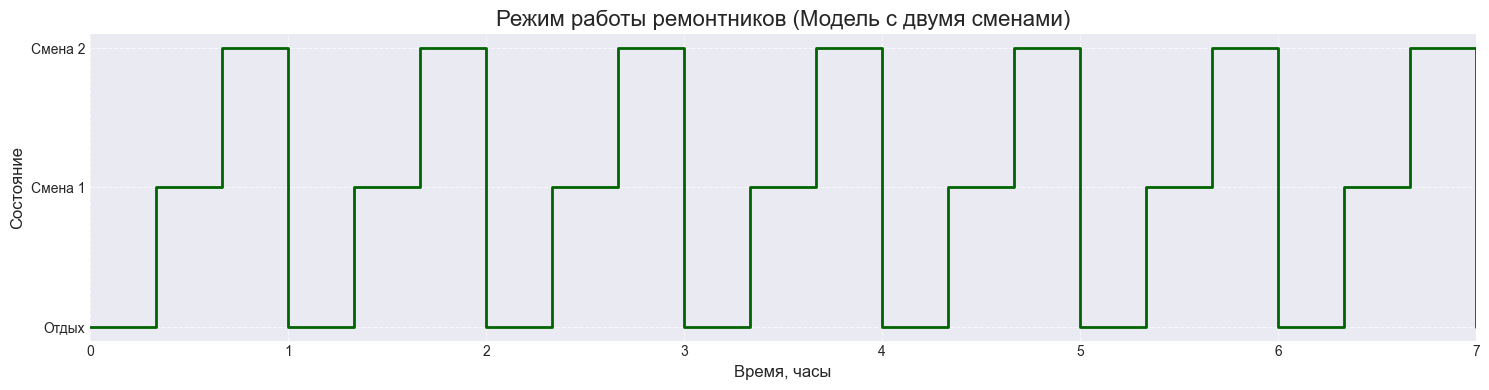

/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_33156/642705469.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=parts_made_ts, ax=axes[0, 0], palette='viridis')
/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_33156/642705469.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=repair_counts_ts, ax=axes[0, 1], palette='plasma')
/var/folders/17/316n_5bx1bx9vjrmz3_tqcrh0000gn/T/ipykernel_33156/642705469.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=failure_durations_ts, ax=ax

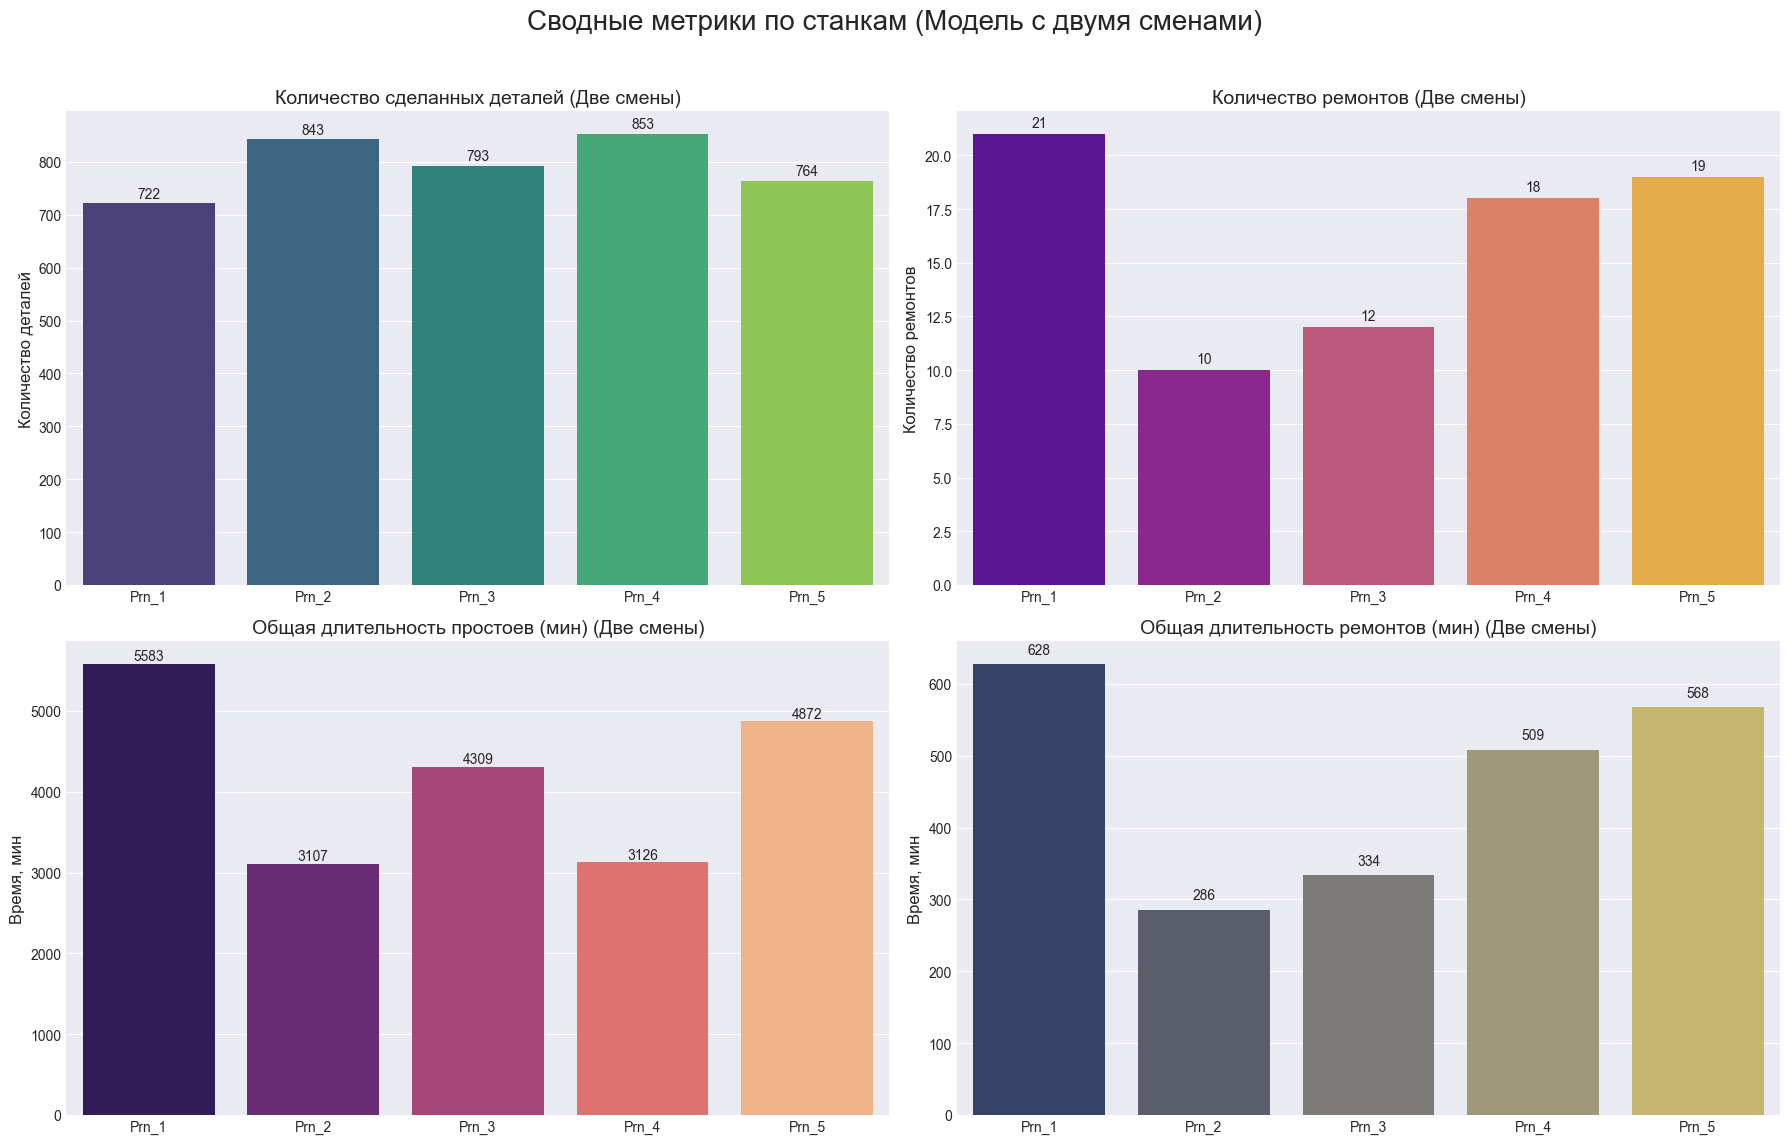

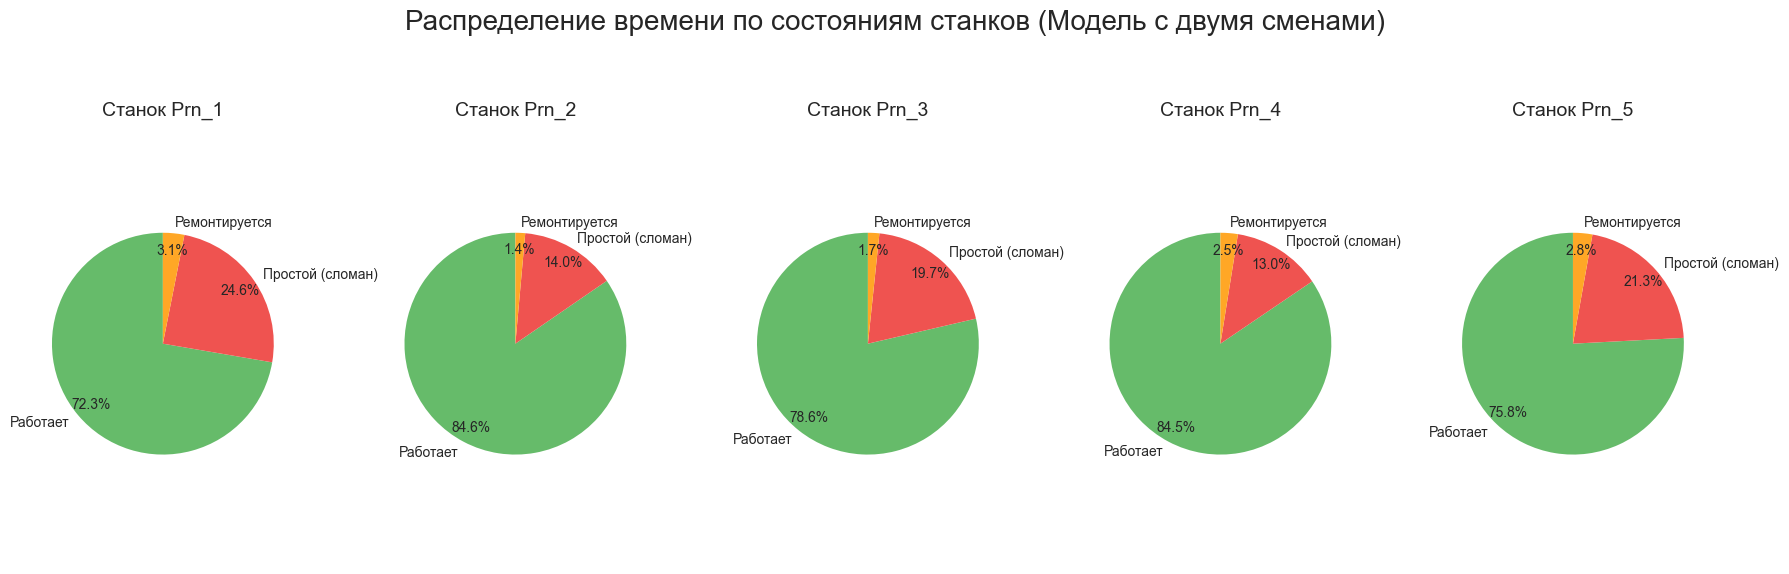

In [7]:
print("\n--- Запуск модели с двумя сменами ремонтников ---")
machines_two_shifts = run_model(two_shifts=True)

print(f'\nРезультаты работы цеха за {WEEKS} недели ({SIM_TIME} мин) - Модель с двумя сменами:')

parts_made_ts = [m.parts_made for m in machines_two_shifts]
repair_counts_ts = [m.repair_cnt for m in machines_two_shifts]
fix_durations_ts = [m.totalFixDuration for m in machines_two_shifts]
failure_durations_ts = [m.totalFailureDuration for m in machines_two_shifts]

for m in machines_two_shifts:
    print(f'  Станок Prn_{m.ID}: сделано {m.parts_made} деталей, проведено {m.repair_cnt} ремонтов, простои: {m.totalFailureDuration:.2f} мин, ремонты: {m.totalFixDuration:.2f} мин')

print(f'\nОбщее количество деталей (две смены): {sum(parts_made_ts)}')
print(f'Общее время простоев станков (две смены): {sum(failure_durations_ts):.2f} мин')
print(f'Общее время ремонтов станков (две смены): {sum(fix_durations_ts):.2f} мин')

# --- Визуализация результатов модели с двумя сменами ---

# 1. График состояния ремонтников (модель с двумя сменами)
plt.figure(figsize=(15, 4))
plt.step([p[1] for p in men_at_work], [p[0] for p in men_at_work], where='post', lw=2, color='darkgreen')
plt.title('Режим работы ремонтников (Модель с двумя сменами)', fontsize=16)
plt.xlabel('Время, часы', fontsize=12)
plt.ylabel('Состояние', fontsize=12)
plt.yticks([0, 1, 2], ['Отдых', 'Смена 1', 'Смена 2'], fontsize=10)
plt.xticks(np.arange(0, SIM_TIME + 1, 24*60), [f'{int(x/(24*60))}' for x in np.arange(0, SIM_TIME + 1, 24*60)], fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 7 * 24 * 60) # Показываем только первую неделю для ясности
plt.tight_layout()
plt.show()

# 2. Гистограммы сравнения по станкам (Модель с двумя сменами)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Сводные метрики по станкам (Модель с двумя сменами)', fontsize=20)
labels = [f'Prn_{i+1}' for i in range(NUM_MACHINES)]
x = np.arange(NUM_MACHINES)
width = 0.6

# Сделано деталей
sns.barplot(x=labels, y=parts_made_ts, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Количество сделанных деталей (Две смены)', fontsize=14)
axes[0, 0].set_ylabel('Количество деталей', fontsize=12)
for index, value in enumerate(parts_made_ts):
    axes[0, 0].text(index, value + 5, str(value), ha='center', va='bottom', fontsize=10)

# Количество ремонтов
sns.barplot(x=labels, y=repair_counts_ts, ax=axes[0, 1], palette='plasma')
axes[0, 1].set_title('Количество ремонтов (Две смены)', fontsize=14)
axes[0, 1].set_ylabel('Количество ремонтов', fontsize=12)
for index, value in enumerate(repair_counts_ts):
    axes[0, 1].text(index, value + 0.2, str(value), ha='center', va='bottom', fontsize=10)

# Длительность простоев
sns.barplot(x=labels, y=failure_durations_ts, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Общая длительность простоев (мин) (Две смены)', fontsize=14)
axes[1, 0].set_ylabel('Время, мин', fontsize=12)
for index, value in enumerate(failure_durations_ts):
    axes[1, 0].text(index, value + 10, f'{value:.0f}', ha='center', va='bottom', fontsize=10)

# Длительность ремонтов
sns.barplot(x=labels, y=fix_durations_ts, ax=axes[1, 1], palette='cividis')
axes[1, 1].set_title('Общая длительность ремонтов (мин) (Две смены)', fontsize=14)
axes[1, 1].set_ylabel('Время, мин', fontsize=12)
for index, value in enumerate(fix_durations_ts):
    axes[1, 1].text(index, value + 10, f'{value:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# 3. Круговые диаграммы состояний станков (Модель с двумя сменами)
fig, axes = plt.subplots(1, NUM_MACHINES, figsize=(18, 6))
fig.suptitle('Распределение времени по состояниям станков (Модель с двумя сменами)', fontsize=20)
state_labels = ['Работает', 'Простой (сломан)', 'Ремонтируется']
colors = ['#66bb6a', '#ef5350', '#ffa726']

for i in range(NUM_MACHINES):
    state_times = [0, 0, 0]
    machine_history = machine_states_history[i] # Используем global machine_states_history, которая обновилась

    for j in range(len(machine_history) - 1):
        current_time, current_state = machine_history[j]
        next_time, _ = machine_history[j + 1]
        duration = next_time - current_time
        state_times[current_state] += duration
    
    last_time, last_state = machine_history[-1]
    state_times[last_state] += SIM_TIME - last_time

    filtered_labels = [state_labels[k] for k, val in enumerate(state_times) if val > 0]
    filtered_times = [val for val in state_times if val > 0]
    filtered_colors = [colors[k] for k, val in enumerate(state_times) if val > 0]

    axes[i].pie(filtered_times, labels=filtered_labels, colors=filtered_colors, 
                autopct='%1.1f%%', startangle=90, pctdistance=0.85, textprops={'fontsize': 10})
    axes[i].set_title(f'Станок Prn_{i+1}', fontsize=14)
    axes[i].axis('equal')

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

## Сравнительный анализ двух моделей

Этот раздел посвящен прямому сравнению результатов двух симуляционных моделей: базовой (одна смена ремонтников) и с двумя сменами. Визуализация в виде столбчатых диаграмм позволяет наглядно оценить влияние изменения режима работы ремонтных бригад на ключевые показатели производительности и эффективности цеха.

### Сравниваемые метрики:

* **Количество сделанных деталей**: Сравнение общей производительности станков в двух режимах.
* **Общая длительность простоев**: Сравнение времени, когда станки простаивали из-за поломок.
* **Общая длительность ремонтов**: Сравнение времени, затраченного на ремонт станков.

Анализ этих графиков поможет определить, какой из режимов работы ремонтников является более эффективным для данного производственного процесса.


--- Сравнительный анализ результатов двух моделей ---


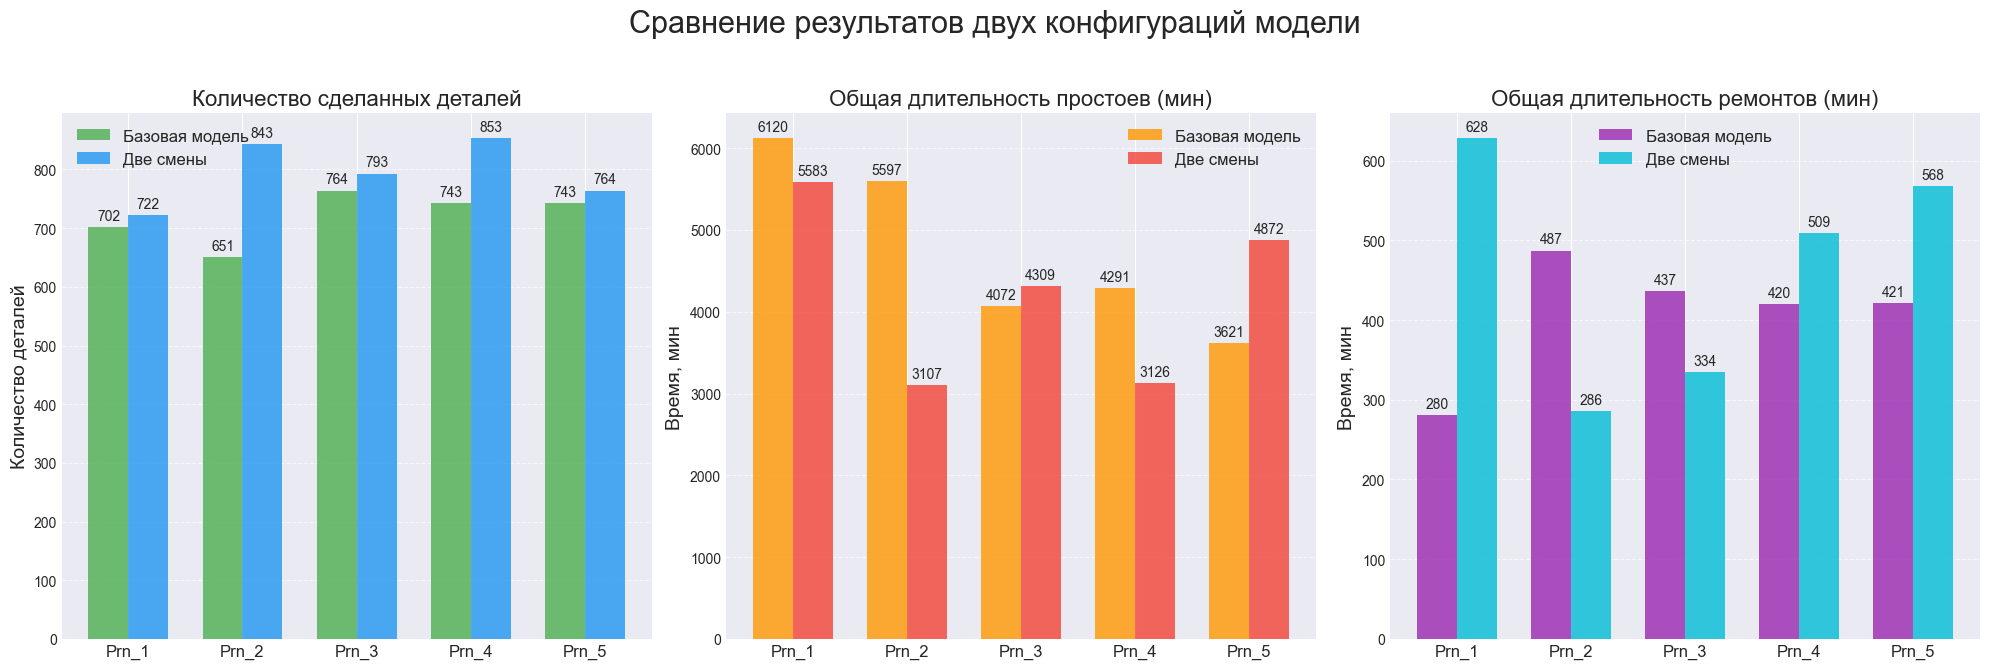

In [8]:
print("\n--- Сравнительный анализ результатов двух моделей ---")
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Сравнение результатов двух конфигураций модели', fontsize=22)

x_labels = [f'Prn_{i+1}' for i in range(NUM_MACHINES)]
x = np.arange(NUM_MACHINES)
width = 0.35 # Ширина столбцов

# 1. Сравнение количества сделанных деталей
bar1 = axes[0].bar(x - width/2, parts_made_base, width, label='Базовая модель', color='#4CAF50', alpha=0.8)
bar2 = axes[0].bar(x + width/2, parts_made_ts, width, label='Две смены', color='#2196F3', alpha=0.8)
axes[0].set_title('Количество сделанных деталей', fontsize=16)
axes[0].set_ylabel('Количество деталей', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].bar_label(bar1, padding=3)
axes[0].bar_label(bar2, padding=3)

# 2. Сравнение общей длительности простоев
bar1 = axes[1].bar(x - width/2, failure_durations_base, width, label='Базовая модель', color='#FF9800', alpha=0.8)
bar2 = axes[1].bar(x + width/2, failure_durations_ts, width, label='Две смены', color='#F44336', alpha=0.8)
axes[1].set_title('Общая длительность простоев (мин)', fontsize=16)
axes[1].set_ylabel('Время, мин', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, fontsize=12)
axes[1].legend(fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].bar_label(bar1, padding=3, fmt='%.0f')
axes[1].bar_label(bar2, padding=3, fmt='%.0f')

# 3. Сравнение общей длительности ремонтов
bar1 = axes[2].bar(x - width/2, fix_durations_base, width, label='Базовая модель', color='#9C27B0', alpha=0.8)
bar2 = axes[2].bar(x + width/2, fix_durations_ts, width, label='Две смены', color='#00BCD4', alpha=0.8)
axes[2].set_title('Общая длительность ремонтов (мин)', fontsize=16)
axes[2].set_ylabel('Время, мин', fontsize=14)
axes[2].set_xticks(x)
axes[2].set_xticklabels(x_labels, fontsize=12)
axes[2].legend(fontsize=12)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].bar_label(bar1, padding=3, fmt='%.0f')
axes[2].bar_label(bar2, padding=3, fmt='%.0f')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Учитываем общий заголовок
plt.show()

## Заключение

В этом разделе подводятся итоги моделирования, обобщаются полученные результаты и делаются выводы о влиянии различных режимов работы ремонтных бригад на эффективность производственного цеха. На основе проведенного анализа можно сформулировать рекомендации по оптимизации процессов.

### Основные выводы:

* **Производительность**: Сравнение общего количества произведенных деталей в двух моделях позволяет оценить, какой режим работы ремонтников способствует более высокой выработке.
* **Время простоев и ремонтов**: Анализ графиков длительности простоев и ремонтов показывает, насколько эффективно каждый режим справляется с устранением поломок и минимизацией потерь рабочего времени.
* **Распределение состояний станков**: Круговые диаграммы состояний станков дают представление о том, какую часть времени станки находятся в рабочем состоянии, а какую - простаивают или ремонтируются, что является ключевым показателем утилизации оборудования.

На основе этих данных можно сделать заключение о том, какой из предложенных подходов к организации работы ремонтных бригад является наиболее оптимальным для конкретных условий производственного цеха.